# 🐦 Pro-Tweet Clustering & Sampling Pipeline
**Goal:** Cluster 1.3M pro-classified tweets using semantic embeddings, then sample 400 proportionally across clusters.

| Step | Method |
|------|--------|
| Embeddings | `paraphrase-MiniLM-L6-v2` (sentence-transformers, GPU-accelerated) |
| Clustering | MiniBatchKMeans on embeddings |
| Sampling | Proportional (largest-remainder) |
| Output | Excel with sampled tweets + cluster summary |

> ⚡ **Runtime tip:** Go to `Runtime → Change runtime type → T4 GPU` before running.


## 1 · Install dependencies

In [6]:
%%capture
!pip install sentence-transformers faiss-cpu pandas openpyxl tqdm matplotlib seaborn
print("✅ Packages installed")

## 2 · Imports & config

In [7]:
import math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
import faiss
import torch

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 3 · Mount Google Drive & load your file

In [8]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [21]:
# ── CONFIG: edit these two lines ──────────────────────────────────────
INPUT_PATH  = "/content/drive/MyDrive/Copy of Dataset-cssr.xlsx"   # path to your Excel file
TEXT_COL    = "Tweet"                            # column containing tweet text
SHEET_NAME  = "PRO"                     # 0 = first sheet, or use sheet name string
# ──────────────────────────────────────────────────────────────────────

df = pd.read_excel(INPUT_PATH, sheet_name=SHEET_NAME, dtype=str)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
df.head(3)


Loaded: 686 rows × 3 columns
Columns: ['#', 'Tweet', 'Label']


,#,Tweet,Label
0,186,Enough of #FarmersProtest these are Khalistani...,PRO (Central Govt / Pro Farm Laws)
1,863,Shame on those still calling #farmersprotest a...,PRO (Central Govt / Pro Farm Laws)
2,1310,What is the offence of disrespecting the Natio...,PRO (Central Govt / Pro Farm Laws)


## 4 · Clean & preview

In [22]:
df = df.dropna(subset=[TEXT_COL]).reset_index(drop=True)
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df = df[df[TEXT_COL].str.len() > 3].reset_index(drop=True)

print(f"Clean rows: {len(df):,}")
print(f"\nSample tweets:")
for t in df[TEXT_COL].sample(5, random_state=0).tolist():
    print(f"  • {t[:120]}")


Clean rows: 686

Sample tweets:
  • If the national capital can be held to ransom with such ease than who would like to invest long term in such a country? 
  • WHO WILL TRUST ON INTOLERANCE @INCIndia WHICH SHOT THE FARMERS IN 1987 ?? #FarmersProtestHijacked #FarmersProtest @BJP4G
  • #FarmersProtest #ModiWithFarmers    there are more advantages in farm bills and looks like a revolution in agriculture r
  • FAKE FARMERS FAKE PROTEST ALL ARE DANGEROUS  FOR SOCIETY  #FarmersProtest
  • Democracy and Communism cannot go together! Communists take advantage of democracy in the world to strengthen the roots 


## 5 · Generate semantic embeddings
> `paraphrase-MiniLM-L6-v2` — 384-dim, fast, excellent for short texts. Processes ~1.3M tweets in ~15–25 mins on T4 GPU.

In [23]:
MODEL_NAME = "paraphrase-MiniLM-L6-v2"
BATCH_SIZE = 512   # increase to 1024 if you have >=16 GB VRAM

print(f"Loading model: {MODEL_NAME}")
model = SentenceTransformer(MODEL_NAME, device=DEVICE)

texts = df[TEXT_COL].tolist()
print(f"Embedding {len(texts):,} tweets in batches of {BATCH_SIZE} …")

embeddings = model.encode(
    texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,   # unit vectors → cosine similarity
)

print(f"\n✅ Embeddings shape: {embeddings.shape}")   # (N, 384)


Loading model: paraphrase-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding 686 tweets in batches of 512 …


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


✅ Embeddings shape: (686, 384)


## 6 · Cluster with FAISS KMeans
> FAISS KMeans is GPU-accelerated and 10-50× faster than scikit-learn for large datasets.

In [24]:
# ── CONFIG ──
N_CLUSTERS = 12    # try 8–20; more clusters = finer topics
# ────────────

use_gpu = DEVICE == "cuda"

print(f"Running FAISS KMeans: k={N_CLUSTERS}, GPU={use_gpu}")

d = embeddings.shape[1]   # 384
kmeans = faiss.Kmeans(
    d,
    N_CLUSTERS,
    niter=30,
    nredo=3,
    verbose=True,
    gpu=use_gpu,
    seed=42,
)
kmeans.train(embeddings.astype(np.float32))

_, cluster_labels = kmeans.index.search(embeddings.astype(np.float32), 1)
df["cluster"] = cluster_labels.flatten()

cluster_sizes = df["cluster"].value_counts().sort_index()
print("\nCluster sizes:")
print(cluster_sizes.to_string())


Running FAISS KMeans: k=12, GPU=True

Cluster sizes:
cluster
0     58
1     53
2     86
3     99
4     91
5     27
6     34
7     55
8     57
9     82
10    30
11    14


## 7 · Visualise clusters (PCA → 2D)
> Projects 384-dim embeddings to 2D for a quick sanity check.

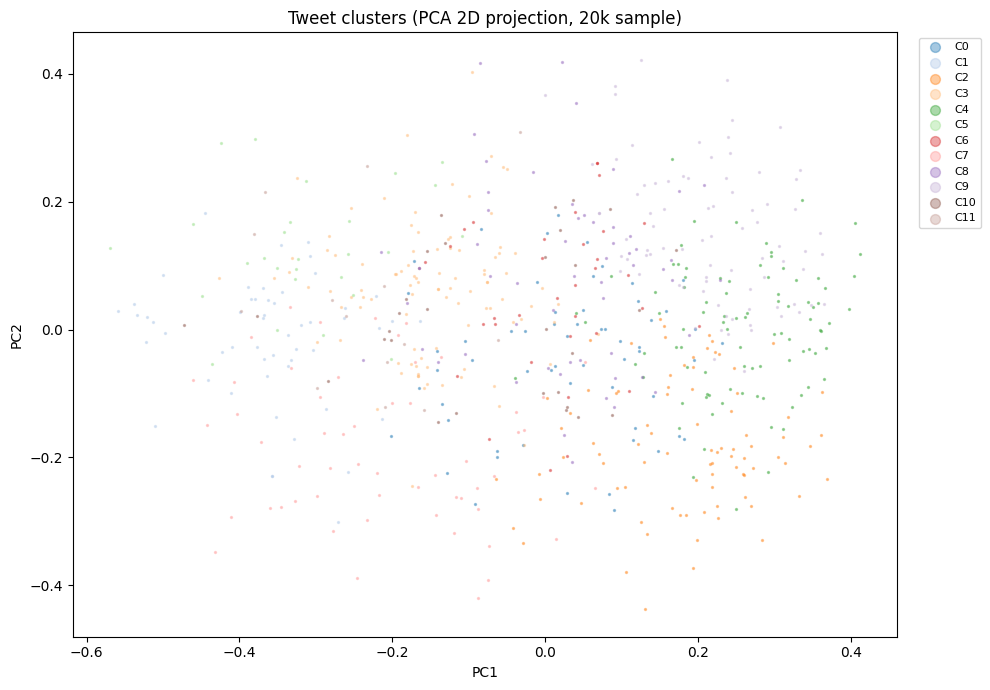

Explained variance: 14.6%


In [25]:
# PCA on a random 20k subset for speed
sample_idx = np.random.choice(len(embeddings), size=min(20_000, len(embeddings)), replace=False)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings[sample_idx])
labels_2d = df["cluster"].values[sample_idx]

palette = sns.color_palette("tab20", N_CLUSTERS)
fig, ax = plt.subplots(figsize=(10, 7))
for cid in range(N_CLUSTERS):
    mask = labels_2d == cid
    ax.scatter(coords[mask, 0], coords[mask, 1],
               s=2, alpha=0.4, color=palette[cid], label=f"C{cid}")

ax.legend(markerscale=5, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_title("Tweet clusters (PCA 2D projection, 20k sample)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.1%}")


## 8 · Top keywords per cluster
> Uses TF-IDF on each cluster's tweets to surface the most characteristic terms.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=50_000, sublinear_tf=True,
                        ngram_range=(1, 2), min_df=5, strip_accents="unicode")
tfidf.fit(df[TEXT_COL].astype(str))
feature_names = np.array(tfidf.get_feature_names_out())

TOP_N = 8
print("Top keywords per cluster:\n")
for cid in range(N_CLUSTERS):
    cluster_tweets = df[df["cluster"] == cid][TEXT_COL].astype(str).tolist()
    if not cluster_tweets:
        continue
    vec = tfidf.transform(cluster_tweets).mean(axis=0)
    scores = np.asarray(vec).flatten()
    top_idx = scores.argsort()[::-1][:TOP_N]
    keywords = ", ".join(feature_names[top_idx])
    print(f"  Cluster {cid:>2d} ({len(cluster_tweets):>8,} tweets): {keywords}")


Top keywords per cluster:

  Cluster  0 (      58 tweets): to, farmersprotest, is, and, the, anti, farmersprotesthijacked, of
  Cluster  1 (      53 tweets): khalistani, terrorists, in, the, khalistani terrorists, farmersprotest, are, is
  Cluster  2 (      86 tweets): protest, farmers, is, fake, the, farmersprotest, this, of
  Cluster  3 (      99 tweets): khalistani, khalistanis, farmersprotest, the, and, are, of, in
  Cluster  4 (      91 tweets): fake, farmers, fake farmers, fake farmersprotest, farmersprotest, the, are, and
  Cluster  5 (      27 tweets): to, of, india, sikhs, the, and, farmersprotest, khalistanis
  Cluster  6 (      34 tweets): fake, fake farmersprotest, to, farmersprotest, of, in, is, fake farmers
  Cluster  7 (      55 tweets): flag, khalistani, protest, khalistani flag, farmersprotest, the, khalistaniterrorists, our
  Cluster  8 (      57 tweets): india, indiawithmodi, to, farmers, farmersprotest, the, and, with
  Cluster  9 (      82 tweets): farmersprotesthi

## 9 · Proportional sampling → 400 tweets

In [27]:
TOTAL_SAMPLE = 400   # change if needed

def proportional_counts(cluster_sizes: pd.Series, total: int) -> dict:
    """Largest-remainder method so counts sum exactly to `total`."""
    exact   = cluster_sizes / cluster_sizes.sum() * total
    floored = exact.apply(math.floor)
    remainders = exact - floored
    shortfall  = total - int(floored.sum())
    floored[remainders.nlargest(shortfall).index] += 1
    return floored.to_dict()

counts = proportional_counts(cluster_sizes, TOTAL_SAMPLE)

print(f"Sampling plan (total = {sum(counts.values())}):\n")
sampled_frames = []
for cid, n in sorted(counts.items()):
    cluster_df = df[df["cluster"] == cid]
    sampled_frames.append(cluster_df.sample(n=n, random_state=42))
    print(f"  Cluster {cid:>2d}: {n:>3d} / {len(cluster_df):>8,}")

sampled = (pd.concat(sampled_frames)
             .sample(frac=1, random_state=42)
             .reset_index(drop=True))

assert len(sampled) == TOTAL_SAMPLE
print(f"\n✅ Sampled {len(sampled)} tweets across {N_CLUSTERS} clusters")
sampled.head()


Sampling plan (total = 400):

  Cluster  0:  34 /       58
  Cluster  1:  31 /       53
  Cluster  2:  50 /       86
  Cluster  3:  58 /       99
  Cluster  4:  53 /       91
  Cluster  5:  16 /       27
  Cluster  6:  20 /       34
  Cluster  7:  32 /       55
  Cluster  8:  33 /       57
  Cluster  9:  48 /       82
  Cluster 10:  17 /       30
  Cluster 11:   8 /       14

✅ Sampled 400 tweets across 12 clusters


,#,Tweet,Label,cluster
0,12822,The #FakeFarmers are actually getting Infected...,PRO (Central Govt / Pro Farm Laws),4
1,9590,"To all those calling this ""Historic moment"", s...",PRO (Central Govt / Pro Farm Laws),7
2,17320,This is what happens when political jokers lik...,PRO (Central Govt / Pro Farm Laws),0
3,38571,If someone thinks that Fake Farmers want govt ...,PRO (Central Govt / Pro Farm Laws),4
4,1630,Villagers at Singhu border tell protesting #Fa...,PRO (Central Govt / Pro Farm Laws),2


## 10 · Sampling breakdown chart

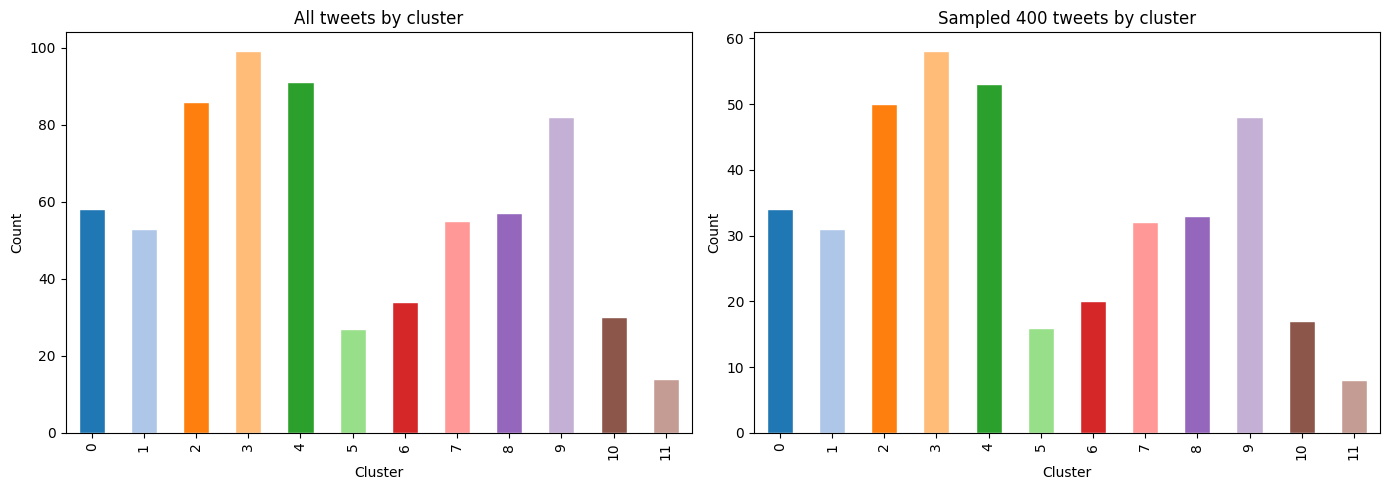

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full cluster sizes
cluster_sizes.plot(kind="bar", ax=axes[0], color=palette, edgecolor="white")
axes[0].set_title("All tweets by cluster"); axes[0].set_xlabel("Cluster"); axes[0].set_ylabel("Count")

# Sampled counts
sampled_counts = sampled["cluster"].value_counts().sort_index()
sampled_counts.plot(kind="bar", ax=axes[1], color=palette, edgecolor="white")
axes[1].set_title(f"Sampled {TOTAL_SAMPLE} tweets by cluster"); axes[1].set_xlabel("Cluster"); axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## 11 · Save output to Google Drive

In [30]:
OUTPUT_PATH = "/content/drive/MyDrive/sampled_400_tweets1.xlsx"

summary = pd.DataFrame({
    "Cluster":           cluster_sizes.index,
    "Total_in_cluster":  cluster_sizes.values,
    "Sampled":           [counts[c] for c in cluster_sizes.index],
})
summary["Sample_%"] = (summary["Sampled"] / summary["Total_in_cluster"] * 100).round(3)

with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    sampled.to_excel(writer, sheet_name="Sampled_400",      index=False)
    summary.to_excel(writer, sheet_name="Cluster_Summary",  index=False)
    df[["cluster"] + [c for c in df.columns if c != "cluster"]].to_excel(
        writer, sheet_name="All_with_clusters", index=False
    )

print(f"✅ Saved to: {OUTPUT_PATH}")
print(f"   • Sheet 'Sampled_400'        → {TOTAL_SAMPLE} sampled tweets")
print(f"   • Sheet 'Cluster_Summary'    → per-cluster stats")
print(f"   • Sheet 'All_with_clusters'  → all {len(df):,} tweets with cluster label")


✅ Saved to: /content/drive/MyDrive/sampled_400_tweets1.xlsx
   • Sheet 'Sampled_400'        → 400 sampled tweets
   • Sheet 'Cluster_Summary'    → per-cluster stats
   • Sheet 'All_with_clusters'  → all 686 tweets with cluster label


## 12 · (Optional) Direct download to your computer

In [31]:
from google.colab import files
files.download(OUTPUT_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>